# 01 — Exploratory Data Analysis

All data here is **synthetic** (see `data/README.md`). This notebook explores the generated PO line dataset before any modeling: class balance, supplier reliability spread, and the seasonal/category effects the generator encodes.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

from po_delay.data_generation import GeneratorParams, generate

df = generate(GeneratorParams(n_orders=40_000, n_suppliers=150, seed=42))
df["order_date"] = pd.to_datetime(df["order_date"])
df.shape

(40000, 24)

In [2]:
df["is_late"].value_counts(normalize=True)

is_late
0    0.78735
1    0.21265
Name: proportion, dtype: float64

## Late rate by category
Custom Fabrication carries a higher risk multiplier in the generator, so it should show up with a higher late rate.

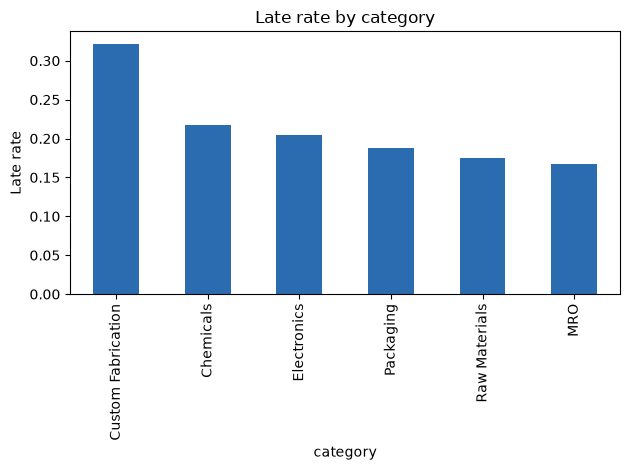

In [3]:
by_category = df.groupby("category")["is_late"].mean().sort_values(ascending=False)
by_category.plot(kind="bar", color="#2b6cb0", title="Late rate by category")
plt.ylabel("Late rate")
plt.tight_layout()

## Late rate over time
Look for seasonal spikes around quarter-ends and the holiday period.

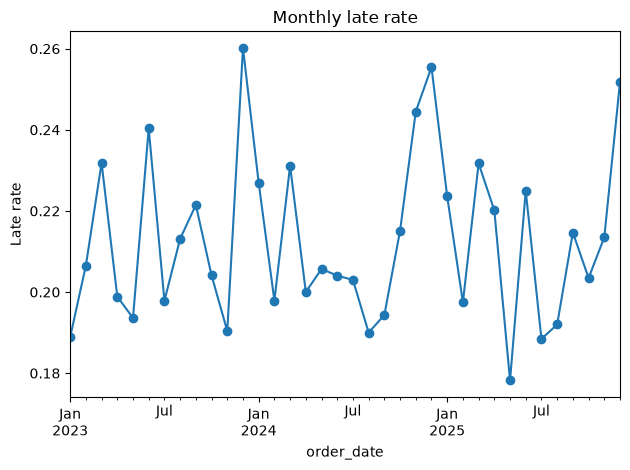

In [4]:
monthly = df.set_index("order_date")["is_late"].resample("MS").mean()
monthly.plot(marker="o", title="Monthly late rate")
plt.ylabel("Late rate")
plt.tight_layout()

## Supplier reliability spread
Trailing on-time rate should show most suppliers clustered near reliable behavior with a long tail of chronically-late ones.

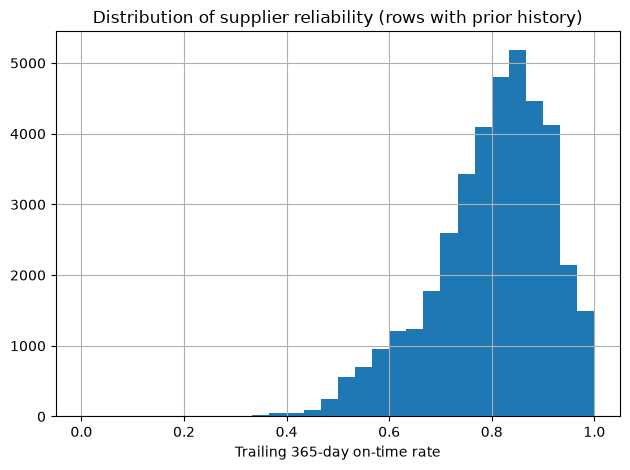

In [5]:
df["supplier_on_time_rate_trailing365"].dropna().hist(bins=30)
plt.xlabel("Trailing 365-day on-time rate")
plt.title("Distribution of supplier reliability (rows with prior history)")
plt.tight_layout()

## Rush orders carry more risk

In [6]:
df.groupby("is_rush_order")["is_late"].mean()

is_rush_order
0    0.198578
1    0.369460
Name: is_late, dtype: float64